In [1]:
from dataset_generator import ApexHeatmapGenerator

generator = ApexHeatmapGenerator()
X_train, y_train = generator.generate_batch(num_samples=10000)

In [2]:
from unet_model import GCHeatmapUNet, WeightedMSELoss
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

model = GCHeatmapUNet()

# 1. Convert to PyTorch Tensors and fix the channel dimension
# X_train shape goes from (5000, 256, 1) to (5000, 1, 256)
X_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
y_tensor = torch.tensor(y_train, dtype=torch.float32).permute(0, 2, 1)

# 2. Create Dataset and DataLoader
batch_size = 32
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [3]:
# 3. Hardware acceleration (use GPU if available)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

# 4. Define Loss and Optimizer
#criterion = WeightedMSELoss(peak_weight=50.0)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Using device: mps


In [4]:
# 5. Training Loop
retrain = False
if retrain:
    epochs = 5

    for epoch in range(epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        
        for batch_X, batch_y in dataloader:
            # Move data to the active device
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(batch_X)
            
            # Compute loss
            loss = criterion(predictions, batch_y)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        # Print average epoch loss
        avg_loss = running_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.6f}")

    # cache the trained model for later evaluation and plotting
    torch.save(model.state_dict(), "gc_heatmap_unet.pth")
else:
    # Load the pre-trained model
    model.load_state_dict(torch.load("gc_heatmap_unet.pth"))
    print("Pre-trained model loaded successfully.")

Pre-trained model loaded successfully.


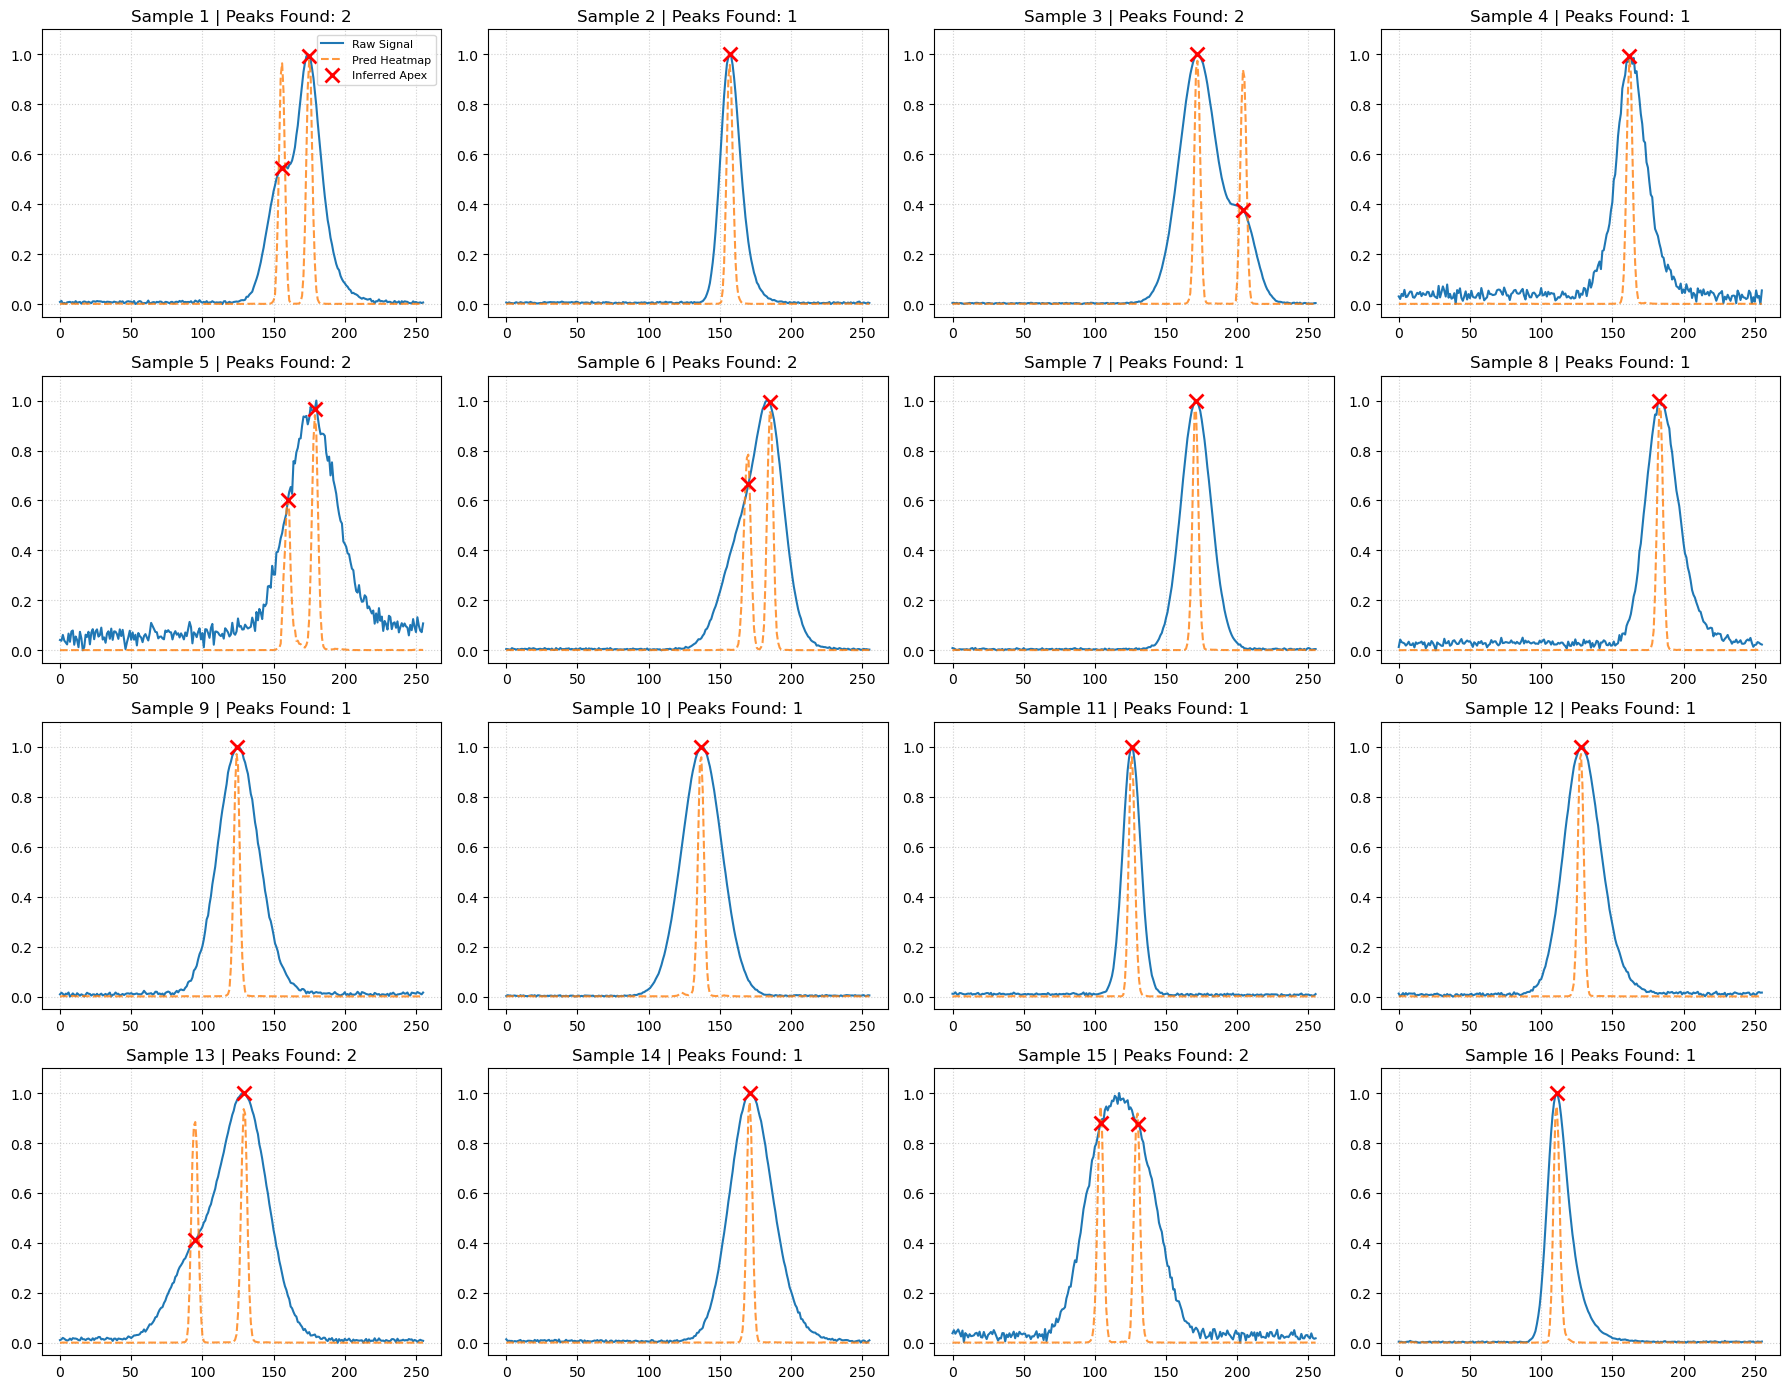

In [5]:
from unet_model import evaluate_and_plot
evaluate_and_plot(model, generator, device=device)

Generating 1000 test samples...
------------------------------
Classification Metrics (Positive = Multi-Peak)
------------------------------
Accuracy:  0.9510
Precision: 0.9935
Recall:    0.9089
F1 Score:  0.9493

Confusion Matrix:
TN: 492   | FP: 3
FN: 46    | TP: 459
------------------------------


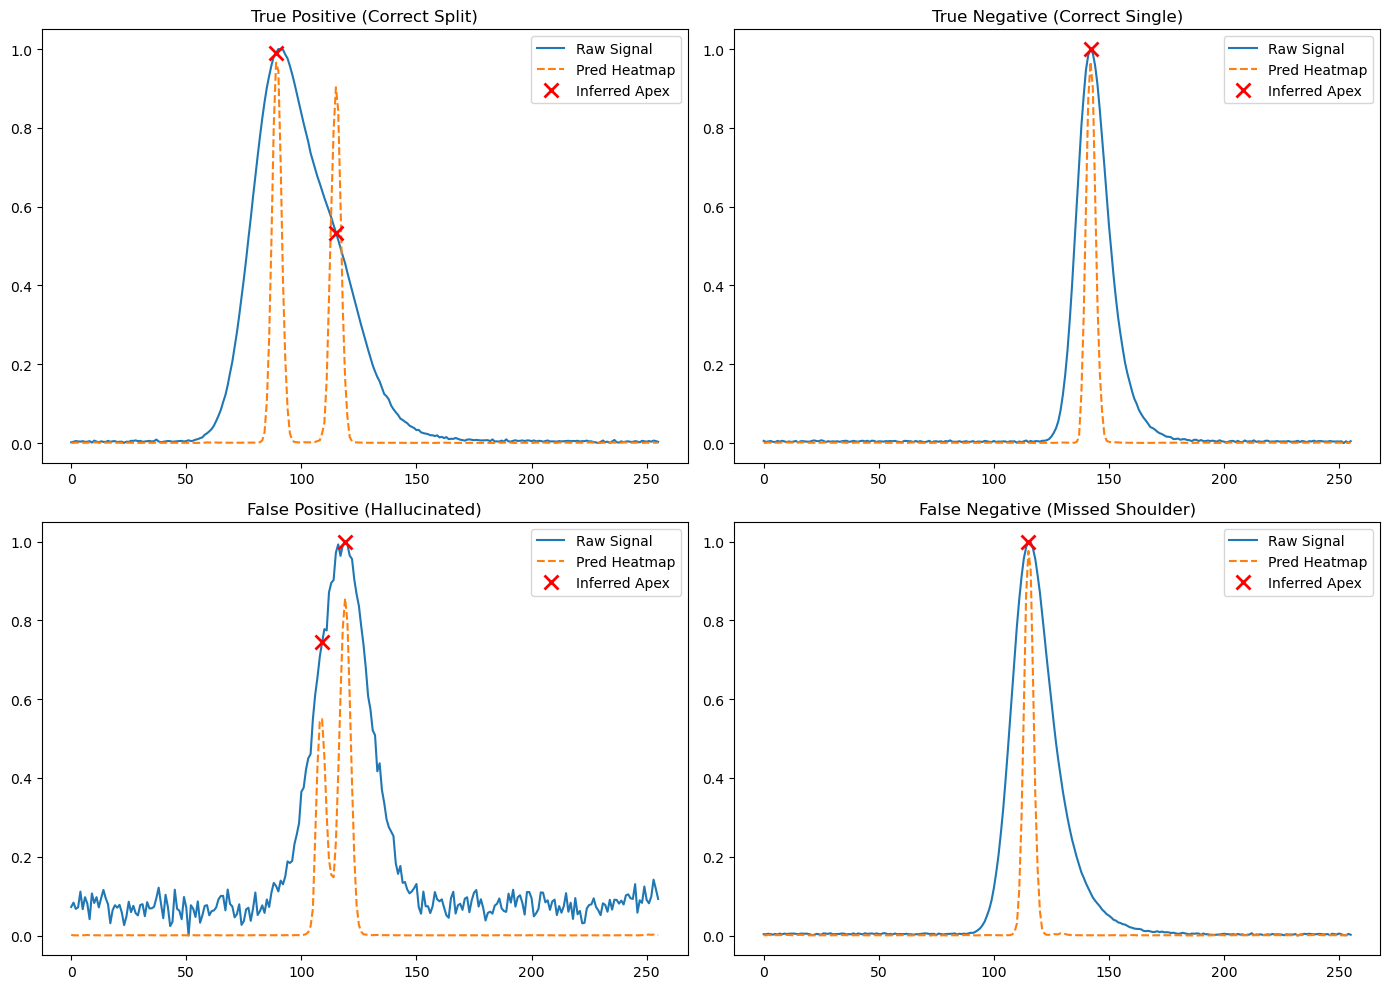

In [28]:
from unet_model import evaluate_classification_metrics

evaluate_classification_metrics(model, generator, num_samples=1000, device=device)

----------------------------------------
Deconvolution Area Analysis
----------------------------------------
Parent Peak:   True Area = 85.00 | Calc = 86.35 | Err = 1.59%
Shoulder Peak: True Area = 22.00 | Calc = 20.07 | Err = 8.79%
----------------------------------------


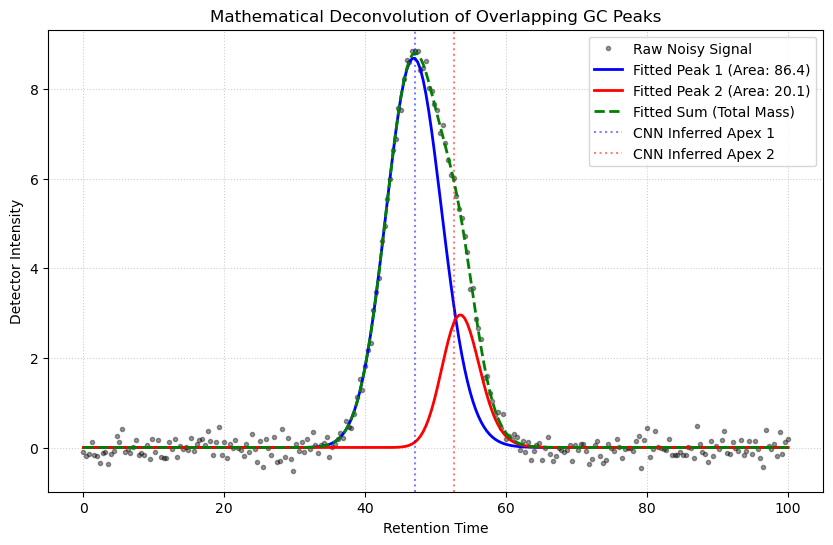

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import exponnorm

# --- Core Math Functions ---
def single_emg(t, amp, mu, sigma, tau):
    sigma = max(sigma, 1e-6) 
    K = tau / sigma if sigma > 0 else 1e-6
    return amp * exponnorm.pdf(t, K, loc=mu, scale=sigma)

def multi_emg(t, *params):
    n_peaks = len(params) // 4
    y_total = np.zeros_like(t)
    for i in range(n_peaks):
        amp, mu, sigma, tau = params[i*4 : (i+1)*4]
        y_total += single_emg(t, amp, mu, sigma, tau)
    return y_total

def deconvolve_peaks(time_array, signal_array, inferred_indices):
    n_peaks = len(inferred_indices)
    p0, bounds_lower, bounds_upper = [], [], []
    
    for idx in inferred_indices:
        guess_mu = time_array[idx]
        guess_amp = signal_array[idx] * 5.0 
        guess_sigma, guess_tau = 3.0, 1.0
        
        p0.extend([guess_amp, guess_mu, guess_sigma, guess_tau])
        bounds_lower.extend([0, time_array[0], 0.1, 0.01])
        bounds_upper.extend([np.inf, time_array[-1], 20.0, 20.0])

    try:
        popt, pcov = curve_fit(
            multi_emg, time_array, signal_array, 
            p0=p0, bounds=(bounds_lower, bounds_upper), maxfev=5000
        )
        return popt
    except RuntimeError:
        print("Optimizer failed to converge.")
        return None

# --- The Area Stress Test ---
def test_deconvolution_accuracy():
    # 1. Setup the Time Domain
    t = np.linspace(0, 100, 256)
    
    # 2. Define the Ground Truth Parameters for a Hidden Shoulder
    # [Amplitude (Area), Mu (Center), Sigma (Width), Tau (Tailing)]
    true_peak1 = [85.0, 45.0, 3.5, 2.0]  # Large parent peak
    true_peak2 = [22.0, 52.0, 2.5, 1.5]  # Hidden shoulder on the tail
    
    # Generate the physics-based additive signal
    clean_y1 = single_emg(t, *true_peak1)
    clean_y2 = single_emg(t, *true_peak2)
    pure_signal = clean_y1 + clean_y2
    
    # Add baseline noise (SNR ~ 50)
    noise = np.random.normal(0, np.max(pure_signal)/50, len(t))
    noisy_signal = pure_signal + noise
    
    # 3. Simulate the Neural Network Output
    # We grab the actual indices, but jitter them slightly (+/- 2 pixels)
    # to prove the optimizer can handle imperfect CNN predictions.
    idx1 = np.argmax(clean_y1) + 1 
    idx2 = np.argmax(clean_y2) - 2
    inferred_indices = [idx1, idx2]
    
    # 4. Run the Optimizer
    popt = deconvolve_peaks(t, noisy_signal, inferred_indices)
    
    if popt is None:
        return
        
    # 5. Extract and Compare the Areas
    calc_area1 = popt[0]
    calc_area2 = popt[4]
    
    err1 = abs(calc_area1 - true_peak1[0]) / true_peak1[0] * 100
    err2 = abs(calc_area2 - true_peak2[0]) / true_peak2[0] * 100
    
    print("-" * 40)
    print("Deconvolution Area Analysis")
    print("-" * 40)
    print(f"Parent Peak:   True Area = {true_peak1[0]:.2f} | Calc = {calc_area1:.2f} | Err = {err1:.2f}%")
    print(f"Shoulder Peak: True Area = {true_peak2[0]:.2f} | Calc = {calc_area2:.2f} | Err = {err2:.2f}%")
    print("-" * 40)
    
    # 6. Plot the Reconstructed Curves
    plt.figure(figsize=(10, 6))
    plt.plot(t, noisy_signal, 'k.', alpha=0.4, label='Raw Noisy Signal')
    
    # Reconstruct the optimized individual curves
    recon_y1 = single_emg(t, *popt[0:4])
    recon_y2 = single_emg(t, *popt[4:8])
    
    plt.plot(t, recon_y1, 'b-', linewidth=2, label=f'Fitted Peak 1 (Area: {calc_area1:.1f})')
    plt.plot(t, recon_y2, 'r-', linewidth=2, label=f'Fitted Peak 2 (Area: {calc_area2:.1f})')
    plt.plot(t, recon_y1 + recon_y2, 'g--', linewidth=2, label='Fitted Sum (Total Mass)')
    
    plt.axvline(x=t[idx1], color='b', linestyle=':', alpha=0.5, label='CNN Inferred Apex 1')
    plt.axvline(x=t[idx2], color='r', linestyle=':', alpha=0.5, label='CNN Inferred Apex 2')
    
    plt.title("Mathematical Deconvolution of Overlapping GC Peaks")
    plt.xlabel("Retention Time")
    plt.ylabel("Detector Intensity")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Execute the test
test_deconvolution_accuracy()